AI 생성 공격 로그 생성 완료 (정제 후: 460건)

위협 탐지 모델 학습 시작
   ↳ Epoch [5/20] - 손실값(Loss): 0.2913
   ↳ Epoch [10/20] - 손실값(Loss): 0.0811
   ↳ Epoch [15/20] - 손실값(Loss): 0.0116
   ↳ Epoch [20/20] - 손실값(Loss): 0.0015

[Test 1] 대표적인 정상 유입 패턴 테스트
[INFO] 정상적인 시스템 이용 패턴 분석됨. 위험도: 0.0% -> 결과: NORMAL

[Test 2] 고위험성 가상 위협 로그 유입 테스트
[ALERT] 실시간 보안 위협 탐지! 위험도: 100.0% -> 결과: ATTACK


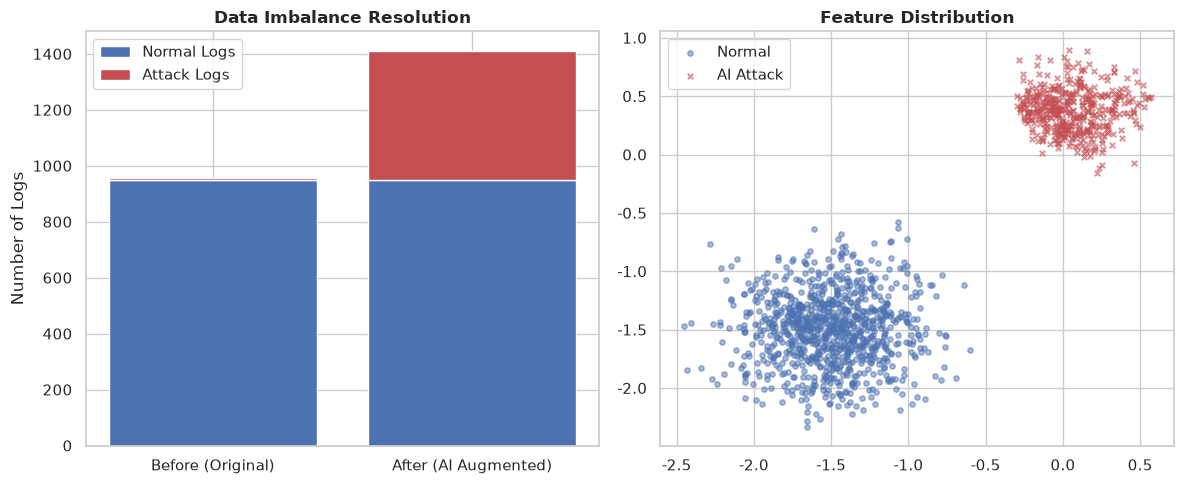

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이상 징후 탐지용 간단한 분류 모델
class AnomalyClassifier(nn.Module):
    def __init__(self, input_dim):
        super(AnomalyClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() 
        )
    def forward(self, x):
        return self.model(x)

# 2. 가상 데이터 생성
class VirtualAttackGenerator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(VirtualAttackGenerator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
            nn.Tanh() 
        )
    def forward(self, z):
        return self.model(z)

# 3. 실시간 추론 함수
def stream_inference(model, raw_log_vector, threshold=0.7):
    model.eval() 
    with torch.no_grad(): 
        log_tensor = torch.tensor([raw_log_vector], dtype=torch.float32)
        anomaly_score = model(log_tensor).item()
        
        if anomaly_score >= threshold:
            print(f"[ALERT] 실시간 보안 위협 탐지! 위험도: {anomaly_score*100:.1f}% -> 결과: ATTACK")
            return "ATTACK"
        else:
            print(f"[INFO] 정상적인 시스템 이용 패턴 분석됨. 위험도: {anomaly_score*100:.1f}% -> 결과: NORMAL")
            return "NORMAL"

if __name__ == "__main__":
    feature_dim = 5
    latent_dim = 10
    
    # [불균형 해소] 가상 시나리오 공격 데이터 500개 생성
    generator = VirtualAttackGenerator(latent_dim, feature_dim)
    noise = torch.randn(500, latent_dim)
    virtual_attack_logs = generator(noise).detach() 
    
    original_attack_count = 5
    
    # 도메인 필터링 정제 규칙 (첫 번째 피처가 -0.3보다 큰 가상 공격 데이터만 남기기)
    mask = virtual_attack_logs[:, 0] > -0.3
    cleaned_attack_logs = virtual_attack_logs[mask]
    ai_generated_count = len(cleaned_attack_logs)
    print(f"AI 생성 공격 로그 생성 완료 (정제 후: {ai_generated_count}건)")
    
    # 정상 데이터 생성: 공격 데이터 영역(원점 주변)과 구분되도록 평균값을 다르게 설정
    normal_logs = torch.randn(950, feature_dim) * 0.3 - 1.5 
    
    # 데이터 결합 및 라벨링 (정상: 0, 공격: 1)
    X_tensor = torch.cat([normal_logs, cleaned_attack_logs], dim=0)
    y_tensor = torch.cat([torch.zeros(950, 1), torch.ones(ai_generated_count, 1)], dim=0)
    
    # 모델 및 학습 가중치 세팅
    classifier = AnomalyClassifier(feature_dim)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.01)
    
    print("\n위협 탐지 모델 학습 시작")
    classifier.train()
    for epoch in range(20):
        optimizer.zero_grad()
        outputs = classifier(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"   ↳ Epoch [{epoch+1}/20] - 손실값(Loss): {loss.item():.4f}")
            
    #시각화 그래프 생성 및 저장
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    categories = ['Before (Original)', 'After (AI Augmented)']
    plt.bar(categories, [950, 950], label='Normal Logs', color='#4C72B0')
    plt.bar(categories, [original_attack_count, ai_generated_count], bottom=[950, 950], label='Attack Logs', color='#C44E52')
    plt.title('Data Imbalance Resolution', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Logs')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(normal_logs[:, 0].tolist(), normal_logs[:, 1].tolist(), alpha=0.5, color='#4C72B0', label='Normal', s=15)
    plt.scatter(cleaned_attack_logs[:, 0].tolist(), cleaned_attack_logs[:, 1].tolist(), alpha=0.6, color='#C44E52', label='AI Attack', s=15, marker='x')
    plt.title('Feature Distribution', fontsize=12, fontweight='bold')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('anomaly_detection_graph.png', dpi=300)
    
    # 실시간 스트리밍 로그 유입 인프라 시뮬레이션 시작
    print("\n[Test 1] 대표적인 정상 유입 패턴 테스트")
    incoming_normal_log = [-1.5, -1.4, -1.6, -1.2, -1.5] # 정상 데이터 영역에 가까운 수치
    stream_inference(classifier, incoming_normal_log, threshold=0.7)
    
    print("\n[Test 2] 고위험성 가상 위협 로그 유입 테스트")
    incoming_attack_log = [0.5, 0.6, 0.4, 0.5, 0.7] # AI 가상 공격 데이터 영역에 가까운 수치
    stream_inference(classifier, incoming_attack_log, threshold=0.7)
